<center> <h1><font size = 16>ANÁLISIS DE CORRELACIÓN</font></h1> </center>

Cuando trabajamos en la modelización de una variable respuesta continua (con predictores continuos o categóricos), lo habitual sería acudir a modelos de regresión que permitan predecir la primera en función de las restantes variables observadas que estén relacionadas con ella. Sin embargo, previamente a dicha modelización, conviene llevar a cabo, aparte de la inspección gráfica, un análisis de asociación.

Cuando las variables explicativas son de tipo continuo y se estudia si las relaciones son de tipo lineal, dicho análisis se denomina de correlación. Cuando disponemos de una única variable predictora, proponemos como medida de asociación lineal el coeficiente de correlación simple; cuando tenemos varios predictores, hemos de trabajar con los coeficientes de correlación parcial, pues el de correlación simple puede dar lugar a conclusiones engañosas.

## Análisis Gráfico de Asociación

El primer paso a dar cuando pretendemos modelizar un banco de datos es llevar a cabo una inspección gráfica de los mismos, con el fin de descubrir de qué tipo son las relaciones entre las variables disponibles, si las hay. Básicamente, los gráficos de asociación son de dos tipos:

### Gráficos de Dispersión

Sirven para visualizar relaciones entre un par de variables continuas. Ejemplo:

In [1]:
x<-c(4.94,5.9,3.05,6.61,6.36,4.92,5.83,4.21,3.75,4.8,3.95,5.3,7.15,4.38,4.42,4.39,4.55,6.68,6.01,5.65,5.54,5.19,
     6.39,2.89,5,5.31,6.18,3.74,4.35,4.32)
y1<-c(1762.66,41885.33,883.73,10703.56,5294,2929.36,2049.4,665.38,1017.73,5643.21,1062.86,64464.37,12246.12,
      943.32,16123.23,4674.16,4314.54, 35907.26,27171.17,17012.14,5833.36,783.38,5330.68,168.06,
      2823.49,3167.86,33221.36,5139.98,982.27,1481.25)
y2<-c(166,364,23,751,613,147,325,59,38,106,50,200,1253,84,82,91,89,772,421,276,298,164,637,22,137,218,509,46,66,84)
y3<-c(15.47,17.5,10.95,19.12,19.24,15.76,16.83,14.7,12.64,15.48,13.96,17.1,20.11,14.09,15.84,14.61,15.48,19.09,
      17.97,17.5,17.62,16.6,18.28,10.45,16.13,16.65,18.3,12.88,14.45,14.66)
y4<-c(1.91,1.63,3.48,1.56,1.57,1.99,1.63,2.45,2.43,1.96,2.51,1.8,1.41,2.25,2.35,2.33,2.06,1.64,1.7,
      1.77,1.91,1.8,1.62,3.36,1.99,1.86,1.61,2.63,2.14,2.27)

In [2]:
library(repr)
options(repr.plot.width=8, repr.plot.height=8)

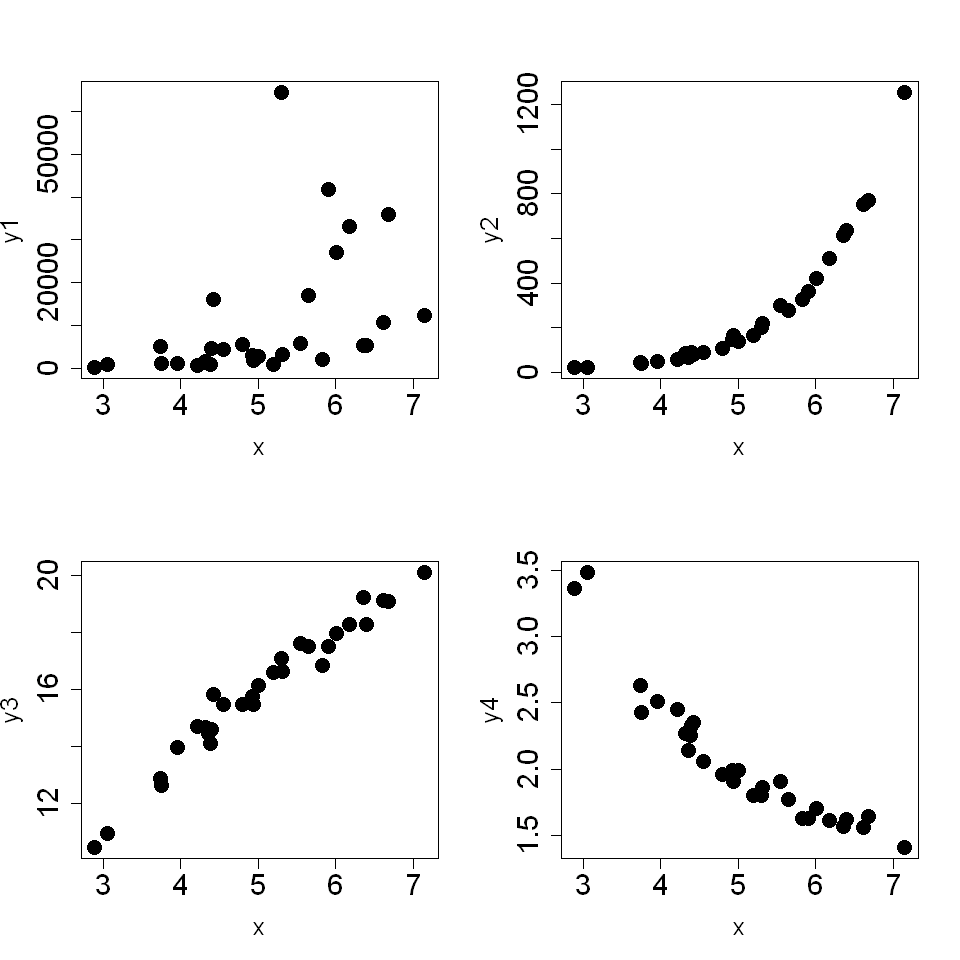

In [3]:
par(mfrow=c(2,2))
plot(x,y1, cex.lab=1.5, cex.axis=1.75, cex = 2, pch = 19)
plot(x,y2, cex.lab=1.5, cex.axis=1.75, cex = 2, pch = 19)
plot(x,y3, cex.lab=1.5, cex.axis=1.75, cex = 2, pch = 19)
plot(x,y4, cex.lab=1.5, cex.axis=1.75, cex = 2, pch = 19)

### Diagramas de Caja

Sirven para visualizar relaciones entre una variable continua y un factor (variable categórica). Ejemplo

In [4]:
x1<-cut(x,3, labels = c('G1', 'G2', 'G3'))

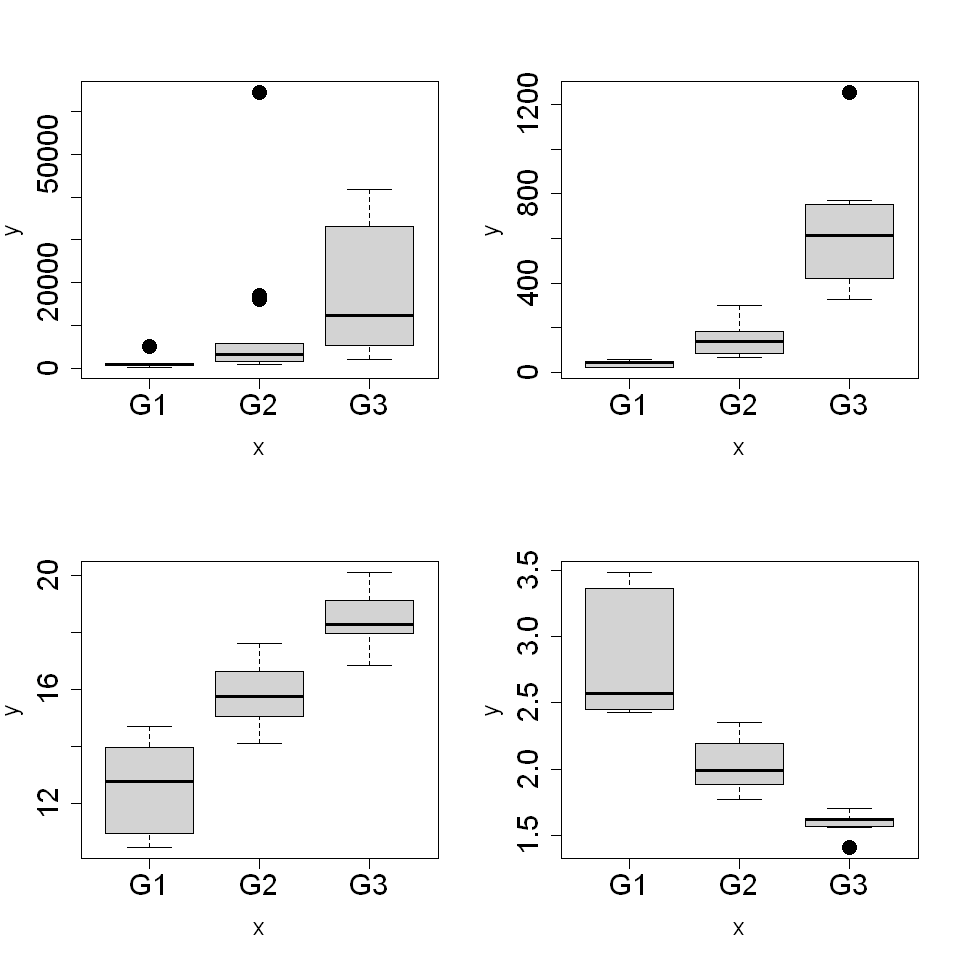

In [5]:
par(mfrow=c(2,2))
plot(x1,y1, cex.lab=1.5, cex.axis=1.75, cex = 2, pch = 19)
plot(x1,y2, cex.lab=1.5, cex.axis=1.75, cex = 2, pch = 19)
plot(x1,y3, cex.lab=1.5, cex.axis=1.75, cex = 2, pch = 19)
plot(x1,y4, cex.lab=1.5, cex.axis=1.75, cex = 2, pch = 19)

## Correlación Lineal Simple

Comenzamos con el caso más sencillo, en el que consideramos una variable respuesta continua $y$ observada y una variable explicativa continua $x$. Un análisis de correlación servirá para poner de manifiesto si existe una relación de tipo lineal entre ambas variables. Otro tipo de relaciones no quedarán manifiestas en la correlación lineal. Si hay correlación lineal simple, tenemos la justificación para ajustar un modelo de regresión lineal simple.

El coeficiente de correlación ($\rho$) de Pearson permite determinar si hay o no correlación lineal. Se define como:

$$
\rho = \frac{Cov(x,y)}{\sqrt{Var(x)Var(y)}}
$$

donde $Var$ identifica la Varianza y $Cov$ la Covarianza:

$$
Cov(x,y) = E[(x-E(x))(y-E(y))]
$$

Si se tiene una muestra $(x_{1},y_{1}), \dots, (x_{n},y_{n})$, el coeficiente de Pearson (_r_, dado que es muestra) se define:

$$
r = \frac{\sum_{i=1}^{n} (x_{i} - \overline{x})(y_{i} - \overline{y})}{\sqrt{\sum_{i=1}^{n}(x_{i}-\overline{x})^{2} \sum_{i=1}^{n}(y_{i}-\overline{y})^{2}}}
$$

#### ¿Cómo se interpreta $\rho$?

* $r=0 \rightarrow$ nada de asociación (lineal)
* $r=1 \rightarrow$ Asociación Lineal Perfecta
* $r<0 \rightarrow$ correlación negativa: $\uparrow x \Rightarrow \downarrow y$. Cuando una aumenta, la otra disminuye
* $r>0 \rightarrow$ correlación positiva: $\uparrow x \Rightarrow \uparrow y$. Cuando una aumenta, la otra también 

### Contraste de Hipótesis

$$
\begin{cases}
H_{0}: \rho = 0 \qquad \text{No Existe Correlación}\\
\\
H_{A}: \rho \neq 0 \qquad \text{Existe Correlación}\\
\end{cases}
$$

* ¿Cómo se resuelve?

Se usa la _z-transformada de Fisher_

\begin{equation}
Z = arctanh(r) = \frac{1}{2} log \left( \frac{1+r}{1-r} \right)
\end{equation}

Que se distribuye: $N \left( arctanh(\rho), 1/(n-3) \right)$ para $n\leq 25$

Sin embargo, se emplea más la _correlación de producto de momentos_ de Pearson:

\begin{equation}
r_{t} = r \sqrt{\frac{n-2}{1-r^{2}}} \sim t_{n-2}
\end{equation}

Se rechaza $H_{0}$ si $|r_{t}|>t_{n-2,1-\alpha/2}$

Existen casos particulares en los que la correlación es alta pero no hay relación lineal:

In [6]:
head(data.frame(x,y1,y2,y3,y4))

,x,y1,y2,y3,y4
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,4.94,1762.66,166,15.47,1.91
2,5.90,41885.33,364,17.50,1.63
3,3.05,883.73,23,10.95,3.48
4,6.61,10703.56,751,19.12,1.56
5,6.36,5294.00,613,19.24,1.57
6,4.92,2929.36,147,15.76,1.99


* Si calculamos los coeficientes, obtenemos:
\begin{eqnarray*}
\rho_{x,y1} &=& 0.441, p.valor=0.01465\\
\rho_{x,y2} &=& 0.877, p.valor=2.171\times 10^{-10}\\
\rho_{x,y3} &=& 0.979, p.valor<2.2\times 10^{-16}\\
\rho_{x,y4} &=& 0.979, p.valor<2.2\times 10^{-16}
\end{eqnarray*}

¿Y la gráfica?

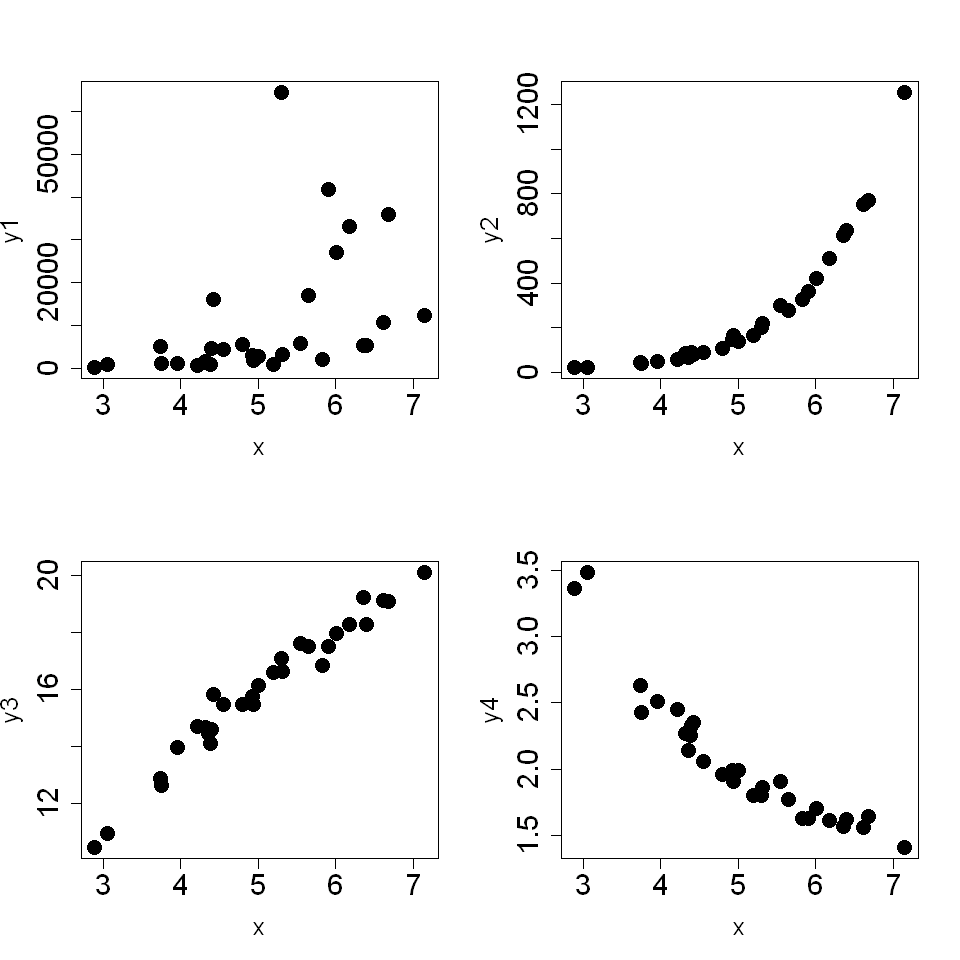

In [7]:
par(mfrow=c(2,2))
plot(x,y1, cex.lab=1.5, cex.axis=1.75, cex = 2, pch = 19)
plot(x,y2, cex.lab=1.5, cex.axis=1.75, cex = 2, pch = 19)
plot(x,y3, cex.lab=1.5, cex.axis=1.75, cex = 2, pch = 19)
plot(x,y4, cex.lab=1.5, cex.axis=1.75, cex = 2, pch = 19)

### Transformaciones Lineales

* Transformamos y Calculamos:

\begin{eqnarray*}
\rho_{ln(x),ln(y1)} &=& 0.698, p.valor=1.813\times 10^{-5}\\
\rho_{x,ln(y2)} &=& 0.996, p.valor<2.2\times 10^{-16}\\
\rho_{x,y3} &=& 0.979, p.valor<2.2\times 10^{-16}\\
\rho_{1/x,y4} &=& 0.982, p.valor<2.2\times 10^{-16}
\end{eqnarray*}

¿Y la gráfica?

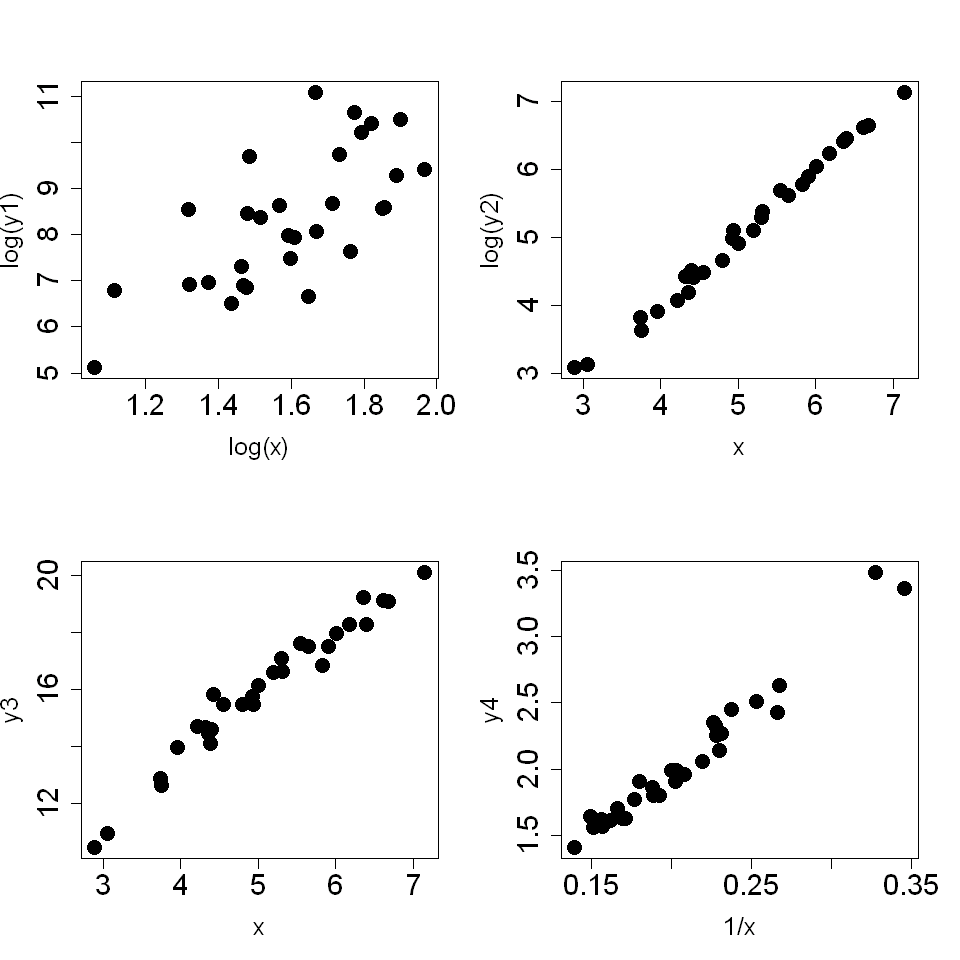

In [8]:
par(mfrow=c(2,2))
plot(log(x),log(y1), cex.lab=1.5, cex.axis=1.75, cex = 2, pch = 19)
plot(x,log(y2), cex.lab=1.5, cex.axis=1.75, cex = 2, pch = 19)
plot(x,y3, cex.lab=1.5, cex.axis=1.75, cex = 2, pch = 19)
plot(1/x,y4, cex.lab=1.5, cex.axis=1.75, cex = 2, pch = 19)

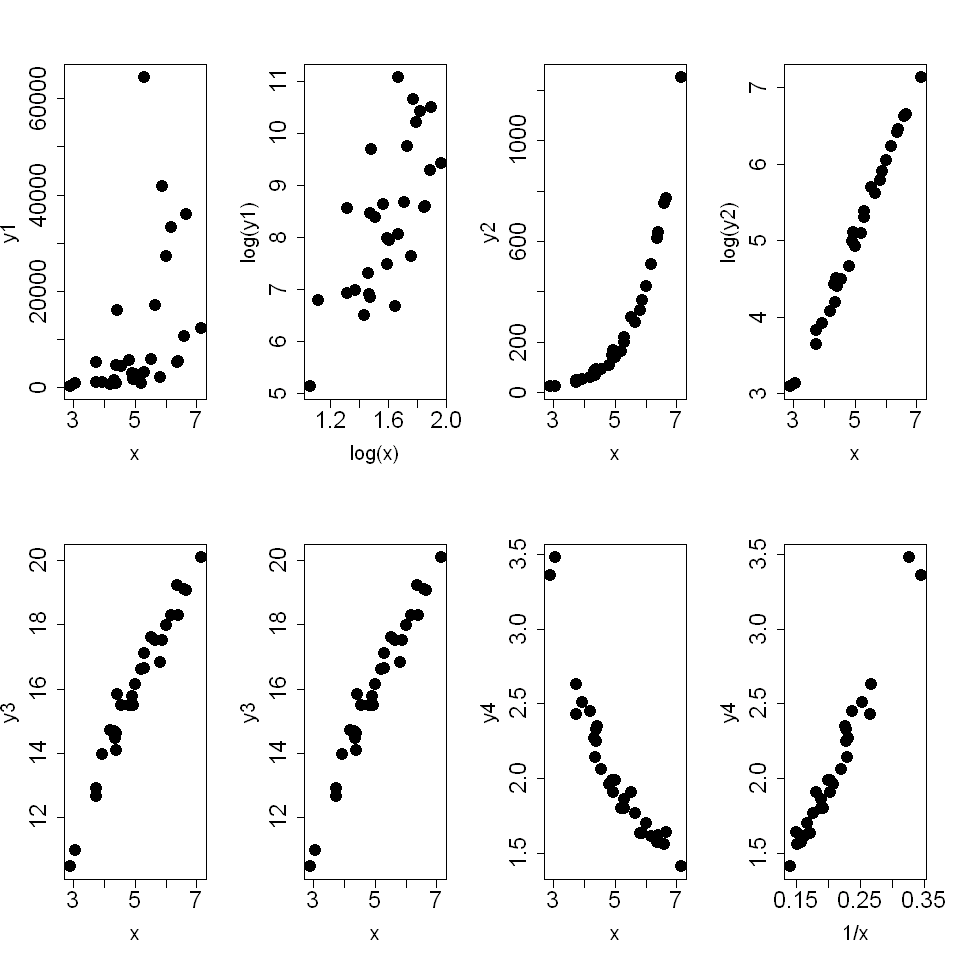

In [9]:
# Comparemos
par(mfrow=c(2,4))
plot(x,y1, cex.lab=1.5, cex.axis=1.75, cex = 2, pch = 19)
plot(log(x),log(y1), cex.lab=1.5, cex.axis=1.75, cex = 2, pch = 19)

plot(x,y2, cex.lab=1.5, cex.axis=1.75, cex = 2, pch = 19)
plot(x,log(y2), cex.lab=1.5, cex.axis=1.75, cex = 2, pch = 19)

plot(x,y3, cex.lab=1.5, cex.axis=1.75, cex = 2, pch = 19)
plot(x,y3, cex.lab=1.5, cex.axis=1.75, cex = 2, pch = 19)

plot(x,y4, cex.lab=1.5, cex.axis=1.75, cex = 2, pch = 19)
plot(1/x,y4, cex.lab=1.5, cex.axis=1.75, cex = 2, pch = 19)

## Análisis de Correlación: Correlación Múltiple y Parcial

* Cuándo se usa?
Cuando se desea analizar un posible modelo multivariado

#### Coef. Corr. Múltiple

\begin{equation}
r_{1 \dots k} = \frac{\left\{ S_{12}S_{22}^{-1}S_{21} \right\}^{1/2}}{S_{11}^{1/2}}
\end{equation}

* $S \rightarrow$ Matriz de Varianzas y Covarianzas
* $S_{11} \rightarrow$ Parte de $S$ que contiene la varianzas $Y$
* $S_{22} \rightarrow$ Parte de $S$ que contiene las varianzas de $X$
* $S_{12} \rightarrow$ Parte de $S$ que contiene las covarianzas entre $X$ e $Y$
* $S_{21} \rightarrow$ Transpuesta de $S_{12}$

#### Coef. Corr. Parcial

\begin{equation}
r_{y.k|(-k)} = \frac{\left[ S_{11,2} \right]_{yl}}{ \left[ S_{11,2} \right]_{yy}^{1/2} \left[ S_{11,2} \right]_{ll}^{1/2}}
\end{equation}


* $S_{11,2} = S_{11} - S_{12}S_{22}^{-1}S_{21}$
* $S \rightarrow$ Matriz de Varianzas y Covarianzas
* $S_{11} \rightarrow$ Parte de $S$ con la varianza de $x_{k}$
* $S_{22} \rightarrow$ Parte de $S$ sin $x_{k}$, $x_{-k}$
* $S_{12} \rightarrow$ Parte de $S$ con las covarianzas $(y,x_{k})$ e $x_{-k}$
* $S_{21} \rightarrow$ Transpuesta de $S_{12}$


#### Hipótesis para Correlación Múltiple:

$$
H_{0}: \rho _{1\dots k} = 0 \quad H_{1}: \rho _{1\dots k} \neq 0
$$

* Contraste:

$$
\frac{(n-k-1)r_{1\dots k}^{2}}{k(1-r_{1\dots k}^{2})} \sim F_{k,n-k-1}
$$


#### Hipótesis para Correlación Parcial:

$$
H_{0}: \rho _{y.k|(q+1,\dots,k)} = 0 \quad H_{1}: \rho _{y.k|(q+1,\dots,k}) \neq 0
$$

* Contraste:

$$
\frac{(n-(k-q)-1)^{1/2}r_{y.k|(-k)}}{k(1-r_{y.k|(-k)}^{2})} \sim t_{n-(k-q)-1}
$$

## Ejemplo

Para realizar el análisis de correlación vamos a emplear los datos correspondientes a una muestra de los resultados Saber Pro para los estudiantes UIS:

In [10]:
datos <- read.csv(url("https://www.dropbox.com/s/h56k6jupp4znytt/sp_uis_2016_2022.csv?dl=1"))
datos <- na.omit(datos)

In [11]:
str(datos)

'data.frame':	5748 obs. of  40 variables:
 $ X            : int  1 2 3 4 5 6 7 8 9 10 ...
 $ Genero       : chr  "F" "M" "F" "M" ...
 $ EstExterior  : chr  "NO" "NO" "NO" "NO" ...
 $ Periodo      : int  2022 2022 2022 2022 2022 2022 2022 2022 2022 2022 ...
 $ Con.Pro      : chr  "EK202250140493" "EK202250194639" "EK202250154993" "EK202250145996" ...
 $ Departamento : chr  "SANTANDER" "SANTANDER" "SANTANDER" "SANTANDER" ...
 $ Municipio    : chr  "PIEDECUESTA" "GÁMBITA" "BUCARAMANGA" "FLORIDABLANCA" ...
 $ EstuArea     : chr  "Area Rural" "Cabecera Municipal" "Cabecera Municipal" "Cabecera Municipal" ...
 $ Matricula    : chr  "No pagó matrícula" "Entre 500 mil y menos de 1 millón" "No pagó matrícula" "Entre 500 mil y menos de 1 millón" ...
 $ PagoBeca     : chr  "Si" "No" "No" "Si" ...
 $ PagoCredito  : chr  "No" "No" "No" "No" ...
 $ PagoPadres   : chr  "No" "Si" "Si" "No" ...
 $ PagoPropio   : chr  "No" "No" "No" "No" ...
 $ Semestre     : chr  "10" "08" "10" "09" ...
 $ EduPadre    

In [12]:
# Organicemos los datos
library(dplyr)
datos <- datos %>% 
  mutate_if(is.character, factor)


Adjuntando el paquete: 'dplyr'


The following objects are masked from 'package:stats':

    filter, lag


The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union




In [13]:
datos$Periodo <- factor(datos$Periodo)
datos$RC_D <- factor(datos$RC_D)
datos$LC_D <- factor(datos$LC_D)
datos$CC_D <- factor(datos$CC_D)
datos$CE_D <- factor(datos$CE_D)
datos$IN_D <- factor(datos$IN_D)

In [14]:
# Extraigamos una muestra
# install.packages('samplingbook')

In [15]:
library(samplingbook)
n <- sample.size.mean(e=0.01*mean(datos$PG), S=sd(datos$PG), level = 0.975, N = length(datos$PG))$n
print(paste0("Tamaño de la muestra: ",n))
muestra<- sample(1:nrow(datos), size=n, replace=FALSE)

Cargando paquete requerido: pps

Cargando paquete requerido: sampling

Cargando paquete requerido: survey

Cargando paquete requerido: grid

Cargando paquete requerido: Matrix

Cargando paquete requerido: survival


Adjuntando el paquete: 'survival'


The following objects are masked from 'package:sampling':

    cluster, strata



Adjuntando el paquete: 'survey'


The following object is masked from 'package:graphics':

    dotchart




[1] "Tamaño de la muestra: 747"


In [16]:
m.datos<-datos[muestra,c('PG','RC','LC','CC','CE','IN')]

In [17]:
# Primero, algunas librerías que vamos a necesitar:
# install.packages(c('corrplot','Hmisc'))

In [18]:
# Este paso sólo es necesario en colab para habilitar algunos aspectos gráficos
# install.packages("BiocManager")
# library(BiocManager)
# BiocManager::install("graph")

In [19]:
#  install.packages('ggm')

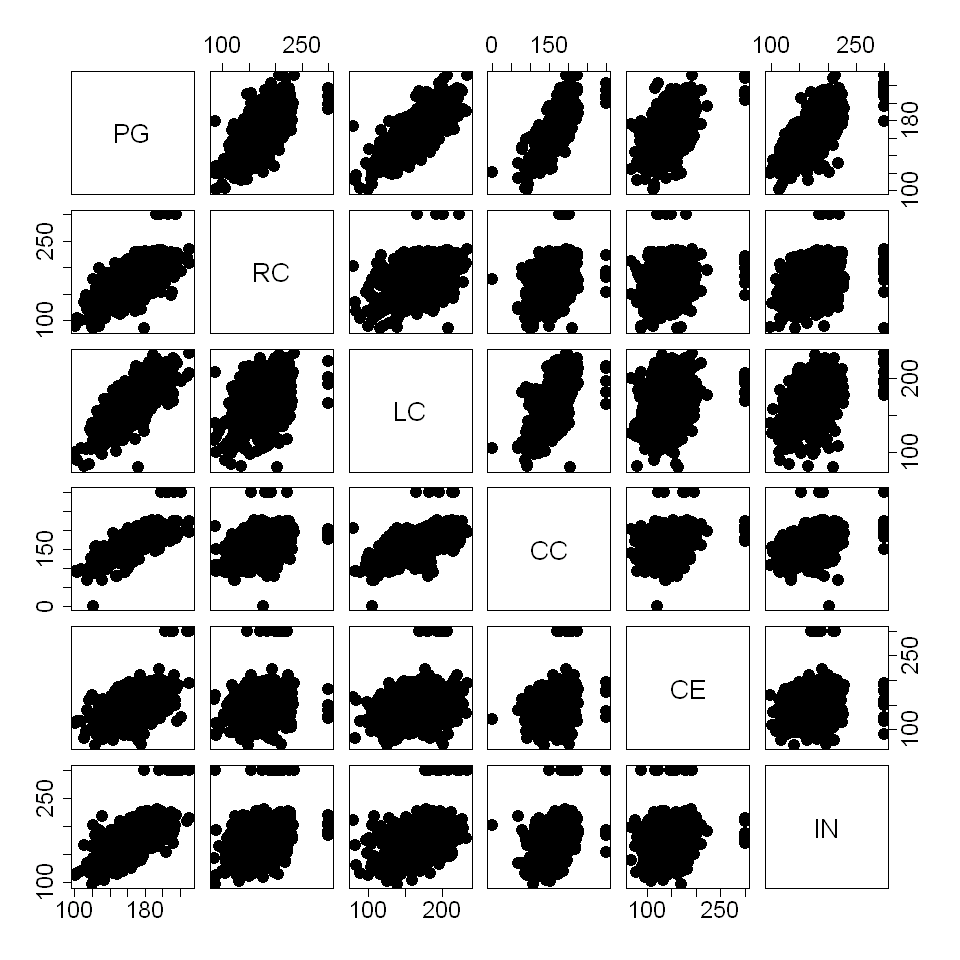

In [20]:
# Hagamos una rápida inspección gráfica. Primero, sólo con las variables continuas
plot(m.datos, cex.lab=1.5, cex.axis=1.75, cex = 2, pch = 19)

In [21]:
# Calculamos, ahora el coeficiente de correlación simple:

round(cor(m.datos),4)

,PG,RC,LC,CC,CE,IN
PG,1.0000,0.6757,0.7999,0.8021,0.5238,0.7132
RC,0.6757,1.0000,0.4575,0.4199,0.1303,0.3600
LC,0.7999,0.4575,1.0000,0.6657,0.2496,0.4794
CC,0.8021,0.4199,0.6657,1.0000,0.2469,0.4803
CE,0.5238,0.1303,0.2496,0.2469,1.0000,0.1909
IN,0.7132,0.3600,0.4794,0.4803,0.1909,1.0000


In [22]:
# el contraste de hipótesis se hace con la función cor.test:
with(m.datos, cor.test(RC,CE))


	Pearson's product-moment correlation

data:  RC and CE
t = 3.5857, df = 745, p-value = 0.0003581
alternative hypothesis: true correlation is not equal to 0
95 percent confidence interval:
 0.05907038 0.20011347
sample estimates:
      cor 
0.1302508 


In [23]:
# Otra forma de hacerlo es:
cor.test(m.datos$LC,m.datos$CC)


	Pearson's product-moment correlation

data:  m.datos$LC and m.datos$CC
t = 24.349, df = 745, p-value < 2.2e-16
alternative hypothesis: true correlation is not equal to 0
95 percent confidence interval:
 0.6237481 0.7038189
sample estimates:
      cor 
0.6656953 


In [24]:
#Funcion para calcular el Coeficiente de correlacion multiple.
rho.mult<-function(datos)
# datos: matriz con las variables del problema.
# La primera columna debe ser la variable respuesta.
# Las restantes p-1 columnas son las variables explicativas.
{
matriz<-var(datos)
# calculo
n<-nrow(datos)
p<-ncol(matriz)
sxx<-matriz[2:p,2:p]
syx<-matrix(matriz[1,2:p],nrow=1)
sxy<-t(syx)
#coeficiente
rho.mult<-sqrt(syx%*%solve(sxx)%*%sxy)/sqrt(matriz[1,1])
cat("\n Coeficiente de correlacion multiple: ",rho.mult,"\n")
#estadistico
if(abs(rho.mult)==1)
stop("Imposible resolver contraste.
Coeficiente de correlacion multiple igual a 1", call. = FALSE)
else{
est<-((n-(p-1)-1)*rho.mult)/((p-1)*(1-rho.mult^2))
#grafico
par(mfrow=c(1,1))
x<-seq(0,qf(0.999,p-1,n-(p-1)-1),length=500)
plot(x,df(x,p-1,n-(p-1)-1),type="l",ylab="densidad",
main="Contraste Correlacion Multiple")
abline(v=qf(0.975,p-1,n-(p-1)-1),col="red")
abline(v=qf(0.025,p-1,n-(p-1)-1),col="red")
abline(v=est,col="blue")
abline(h=0)
legend(qf(0.98,p-1,n-(p-1)-1),pf((p+3)/(n-p),p-1,n-(p-1)-1),
c("Estadistico","Region Critica"),lty=rep(1,2),
col=c("blue","red"),bty="n")
cat("\n Estadistico de contraste: ",round(est,3),"\n")
cat("\n p-valor: ",round(2*(1-pf(est,p-1,n-(p-1)-1)),3),"\n\n")}
return(invisible())
}

In [25]:
head(m.datos)

,PG,RC,LC,CC,CE,IN
,<int>,<int>,<int>,<int>,<int>,<int>
4125,196,213,201,219,183,164
2784,185,181,194,201,147,202
1145,179,162,202,164,172,195
3192,156,131,143,144,157,203
3063,183,209,190,168,155,191
2466,200,216,216,208,155,205



 Coeficiente de correlacion multiple:  0.9999124 

 Estadistico de contraste:  846008.7 

 p-valor:  0 



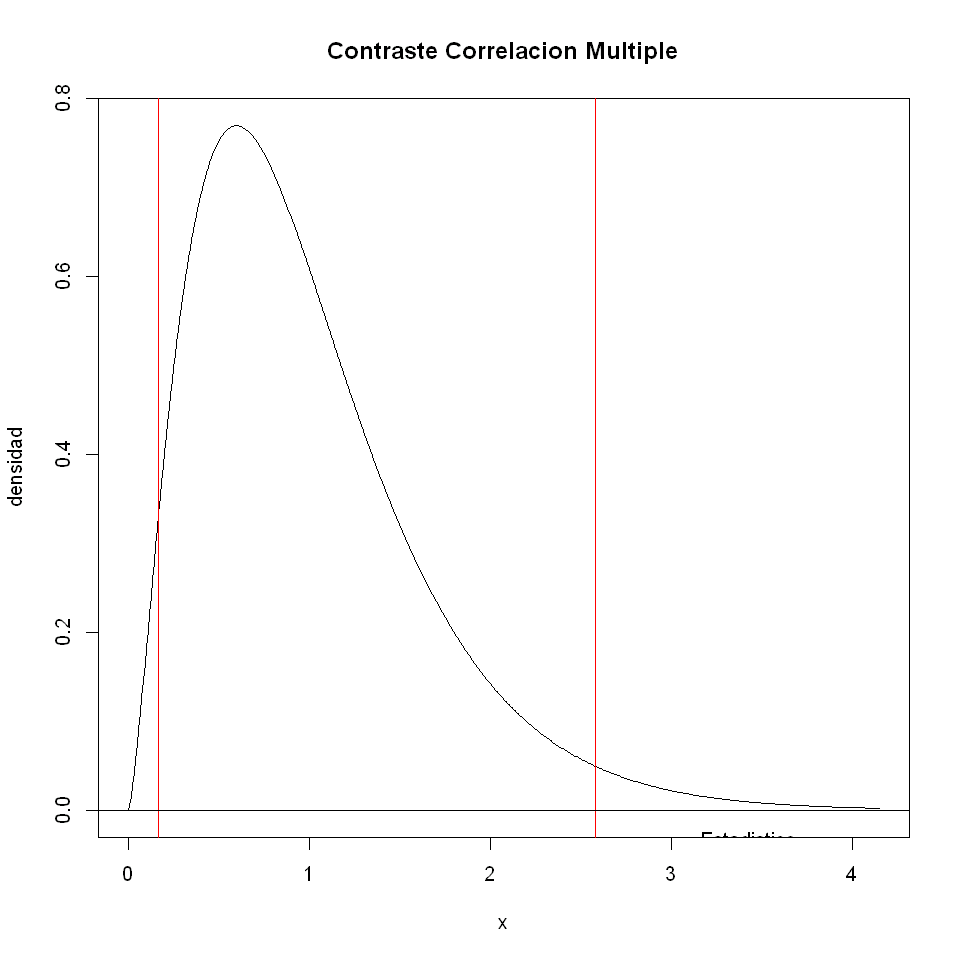

In [26]:
rho.mult(m.datos)

In [27]:
# Correlación Parcial
library(ggm)

In [28]:
round(parcor(cov(m.datos)),4)

,PG,RC,LC,CC,CE,IN
PG,1.0000,0.9986,0.9973,0.9981,0.9989,0.9985
RC,0.9986,1.0000,-0.9951,-0.9963,-0.9976,-0.9967
LC,0.9973,-0.9951,1.0000,-0.9931,-0.9959,-0.9950
CC,0.9981,-0.9963,-0.9931,1.0000,-0.9967,-0.9958
CE,0.9989,-0.9976,-0.9959,-0.9967,1.0000,-0.9972
IN,0.9985,-0.9967,-0.9950,-0.9958,-0.9972,1.0000


In [29]:
round(correlations(cov(m.datos)),4)

,PG,RC,LC,CC,CE,IN
PG,1.0000,0.9986,0.9973,0.9981,0.9989,0.9985
RC,0.6757,1.0000,-0.9951,-0.9963,-0.9976,-0.9967
LC,0.7999,0.4575,1.0000,-0.9931,-0.9959,-0.9950
CC,0.8021,0.4199,0.6657,1.0000,-0.9967,-0.9958
CE,0.5238,0.1303,0.2496,0.2469,1.0000,-0.9972
IN,0.7132,0.3600,0.4794,0.4803,0.1909,1.0000


In [30]:
# Veamos cómo podemos aplicar el test de correlación a una matriz de datos:
library("Hmisc")


Adjuntando el paquete: 'Hmisc'


The following object is masked from 'package:ggm':

    rcorr


The following object is masked from 'package:survey':

    deff


The following objects are masked from 'package:dplyr':

    src, summarize


The following objects are masked from 'package:base':

    format.pval, units




In [31]:
rcorr(as.matrix(m.datos))

     PG   RC   LC   CC   CE   IN
PG 1.00 0.68 0.80 0.80 0.52 0.71
RC 0.68 1.00 0.46 0.42 0.13 0.36
LC 0.80 0.46 1.00 0.67 0.25 0.48
CC 0.80 0.42 0.67 1.00 0.25 0.48
CE 0.52 0.13 0.25 0.25 1.00 0.19
IN 0.71 0.36 0.48 0.48 0.19 1.00

n= 747 


P
   PG    RC    LC    CC    CE    IN   
PG       0e+00 0e+00 0e+00 0e+00 0e+00
RC 0e+00       0e+00 0e+00 4e-04 0e+00
LC 0e+00 0e+00       0e+00 0e+00 0e+00
CC 0e+00 0e+00 0e+00       0e+00 0e+00
CE 0e+00 4e-04 0e+00 0e+00       0e+00
IN 0e+00 0e+00 0e+00 0e+00 0e+00      

In [32]:
# Un método gráfico

M<-cor(m.datos)
round(M,2)

,PG,RC,LC,CC,CE,IN
PG,1.00,0.68,0.80,0.80,0.52,0.71
RC,0.68,1.00,0.46,0.42,0.13,0.36
LC,0.80,0.46,1.00,0.67,0.25,0.48
CC,0.80,0.42,0.67,1.00,0.25,0.48
CE,0.52,0.13,0.25,0.25,1.00,0.19
IN,0.71,0.36,0.48,0.48,0.19,1.00


In [33]:
library(corrplot)

corrplot 0.95 loaded



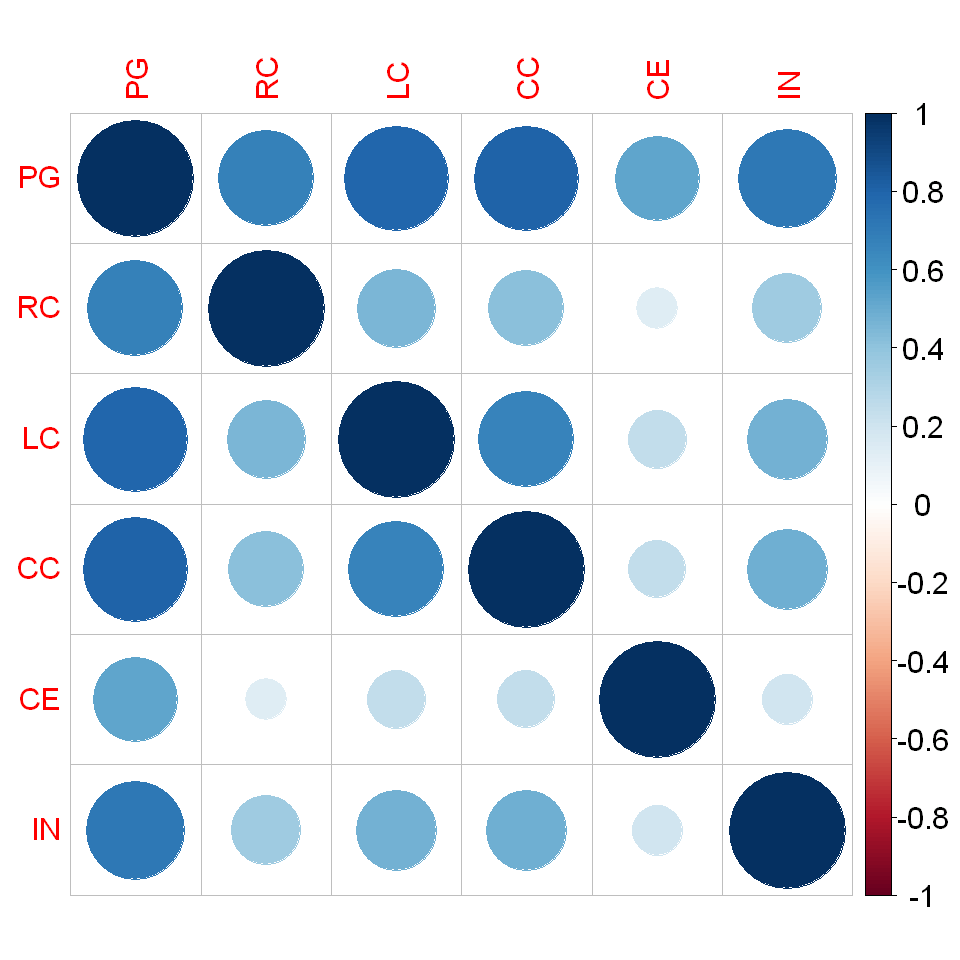

In [34]:
corrplot(M, method="circle", cl.cex = 1.5, number.cex = 2, number.font = 3, tl.cex = 1.5)

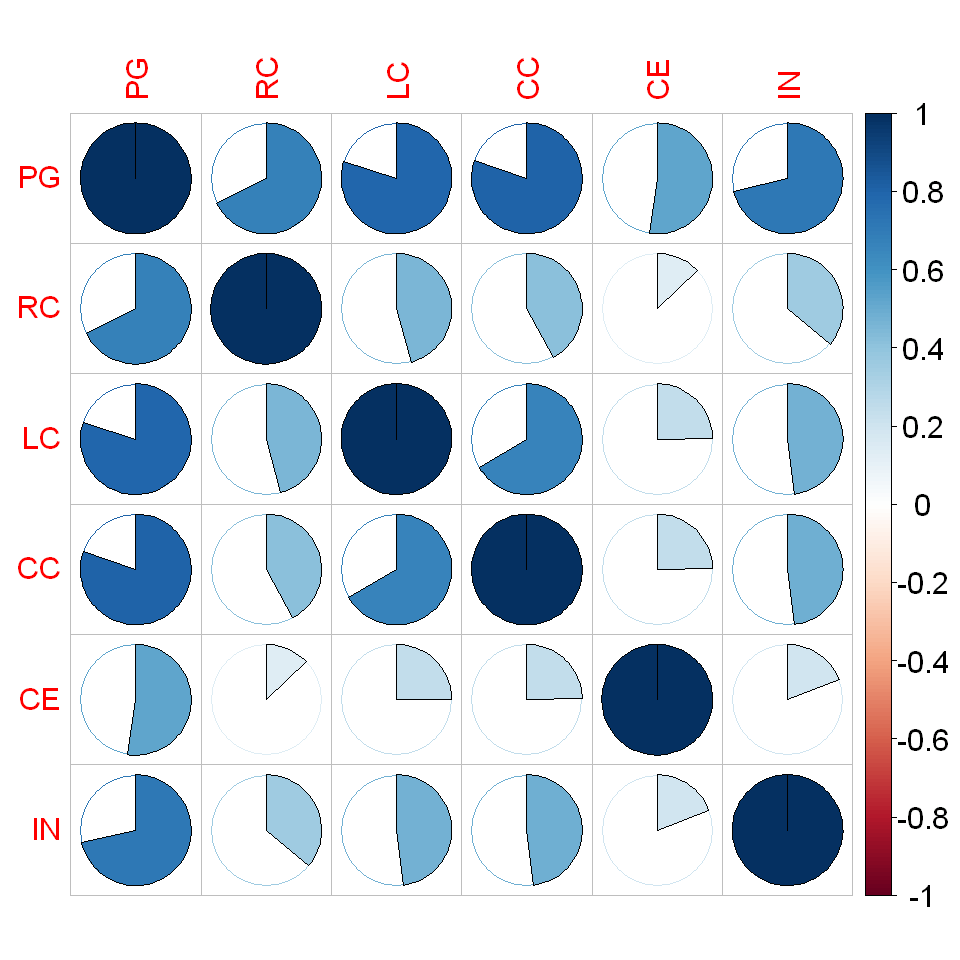

In [35]:
corrplot(M, method="pie", cl.cex = 1.5, number.cex = 2, number.font = 3, tl.cex = 1.5)

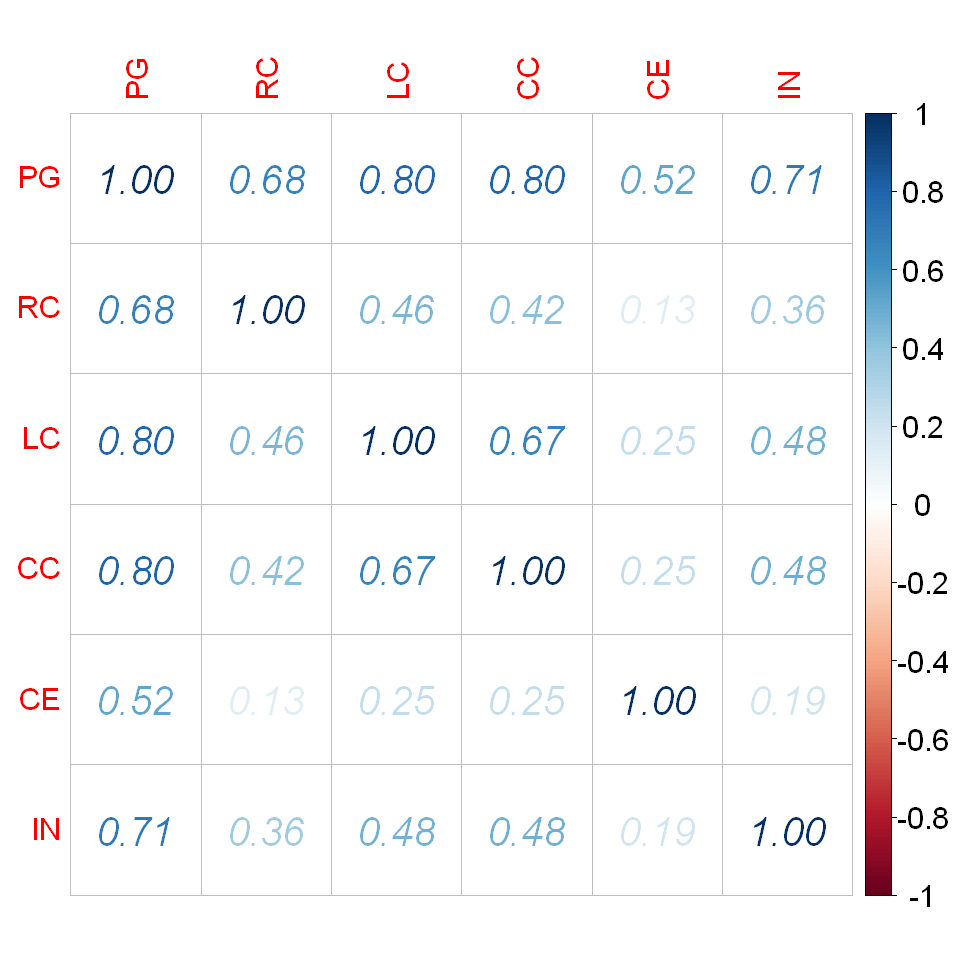

In [36]:
corrplot(M, method="number", cl.cex = 1.5, number.cex = 2, number.font = 3, tl.cex = 1.5)

In [37]:
head(m.datos)

,PG,RC,LC,CC,CE,IN
,<int>,<int>,<int>,<int>,<int>,<int>
4125,196,213,201,219,183,164
2784,185,181,194,201,147,202
1145,179,162,202,164,172,195
3192,156,131,143,144,157,203
3063,183,209,190,168,155,191
2466,200,216,216,208,155,205


In [38]:
# Test de correlación con IC:
cor.mtest(m.datos, conf.level = 0.95)

,PG,RC,LC,CC,CE,IN
PG,0.000000e+00,9.231565e-101,2.178008e-167,5.785550e-169,7.300140e-54,4.445992e-117
RC,9.231565e-101,0.000000e+00,6.375450e-40,2.916615e-33,3.581030e-04,2.858568e-24
LC,2.178008e-167,6.375450e-40,0.000000e+00,8.494667e-97,4.538836e-12,3.411074e-44
CC,5.785550e-169,2.916615e-33,8.494667e-97,0.000000e+00,7.723062e-12,2.275056e-44
CE,7.300140e-54,3.581030e-04,4.538836e-12,7.723062e-12,0.000000e+00,1.470334e-07
IN,4.445992e-117,2.858568e-24,3.411074e-44,2.275056e-44,1.470334e-07,0.000000e+00
,PG,RC,LC,CC,CE,IN
PG,1.0000000,0.63476244,0.7725216,0.7749598,0.46971151,0.6760677
RC,0.6347624,1.00000000,0.3988953,0.3589538,0.05907038,0.2958682
LC,0.7725216,0.39889525,1.0000000,0.6237481,0.18107459,0.4222118


In [39]:
rcorr(as.matrix(m.datos))

     PG   RC   LC   CC   CE   IN
PG 1.00 0.68 0.80 0.80 0.52 0.71
RC 0.68 1.00 0.46 0.42 0.13 0.36
LC 0.80 0.46 1.00 0.67 0.25 0.48
CC 0.80 0.42 0.67 1.00 0.25 0.48
CE 0.52 0.13 0.25 0.25 1.00 0.19
IN 0.71 0.36 0.48 0.48 0.19 1.00

n= 747 


P
   PG    RC    LC    CC    CE    IN   
PG       0e+00 0e+00 0e+00 0e+00 0e+00
RC 0e+00       0e+00 0e+00 4e-04 0e+00
LC 0e+00 0e+00       0e+00 0e+00 0e+00
CC 0e+00 0e+00 0e+00       0e+00 0e+00
CE 0e+00 4e-04 0e+00 0e+00       0e+00
IN 0e+00 0e+00 0e+00 0e+00 0e+00      

In [40]:
args(corrplot)

function (corr, method = c("circle", "square", "ellipse", "number", 
    "shade", "color", "pie"), type = c("full", "lower", "upper"), 
    col = NULL, col.lim = NULL, is.corr = TRUE, bg = "white", 
    title = "", add = FALSE, diag = TRUE, outline = FALSE, mar = c(0, 
        0, 0, 0), addgrid.col = NULL, addCoef.col = NULL, addCoefasPercent = FALSE, 
    order = c("original", "AOE", "FPC", "hclust", "alphabet"), 
    hclust.method = c("complete", "ward", "ward.D", "ward.D2", 
        "single", "average", "mcquitty", "median", "centroid"), 
    addrect = NULL, rect.col = "black", rect.lwd = 2, tl.pos = NULL, 
    tl.cex = 1, tl.col = "red", tl.offset = 0.4, tl.srt = 90, 
    cl.pos = NULL, cl.length = NULL, cl.cex = 0.8, cl.ratio = 0.15, 
    cl.align.text = "c", cl.offset = 0.5, number.cex = 1, number.font = 2, 
    number.digits = NULL, addshade = c("negative", "positive", 
        "all"), shade.lwd = 1, shade.col = "white", transKeepSign = TRUE, 
    p.mat = NULL, sig.level = 0.05, insig = c("pch", "p-value", 
        "blank", "n", "label_sig"), pch = 4, pch.col = "black", 
    pch.cex = 3, plotCI = c("n", "square", "circle", "rect"), 
    lowCI.mat = NULL, uppCI.mat = NULL, na.label = "?", na.label.col = "black", 
    win.asp = 1, ...) 
NULL

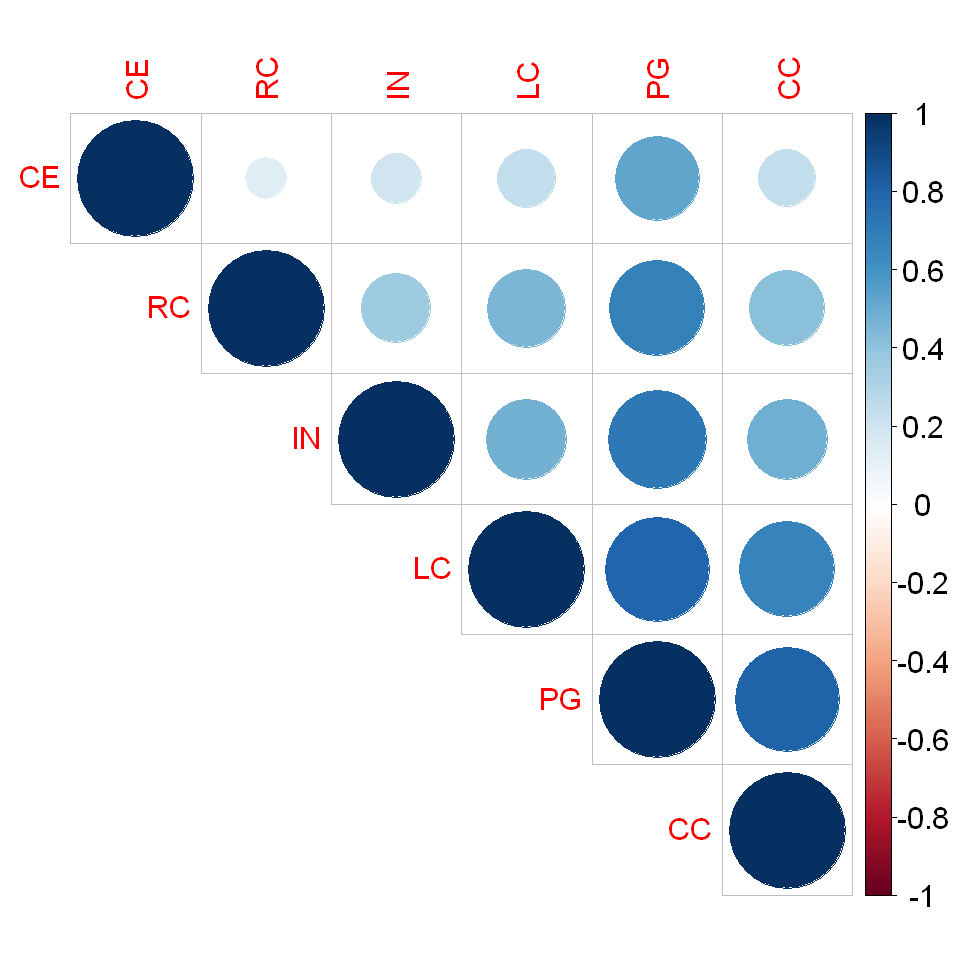

In [41]:
# Marcando los coeficientes insignificantes de acuerdo a un nivel p
cor_5 <- rcorr(as.matrix(m.datos))
M <- cor_5$r
p_mat <- cor_5$P
p_mat[is.na(p_mat)] <- 0
corrplot(M, type = "upper", order = "hclust", p.mat = p_mat, sig.level = 0.01, cl.cex = 1.5, number.cex = 2, number.font = 3, tl.cex = 1.5)

In [ ]:
#save(list=ls(all = T), file = 'datos.RData')
#load('datos.RData')